In [1]:
import os

# Source path from the file system
source_path = '/content/data/cifar-10-python.tar.gz'
dest_path = './cifar-10-python.tar.gz'

if os.path.exists(source_path):
    !cp {source_path} {dest_path}
    print(f"Copied {source_path} to current directory.")
else:
    print("File not found in /content/data/, downloading from source...")
    !wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

File not found in /content/data/, downloading from source...
--2026-03-30 16:41:07--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  50.1MB/s    in 3.6s    

2026-03-30 16:41:10 (44.9 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]



In [2]:
import tarfile
import os

# Tên file đã tải xuống từ bước 3.1
file_name = 'cifar-10-python.tar.gz'
output_dir = './output_folder'

if os.path.exists(file_name):
    with tarfile.open(file_name, 'r:gz') as tar:
        tar.extractall(path=output_dir)
        print(f"Đã giải nén thành công vào {output_dir}")
else:
    print("Lỗi: Không tìm thấy file cifar-10-python.tar.gz. Hãy chạy lại cell tải dữ liệu ở mục 3.1.")

/tmp/ipykernel_12795/2058467999.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=output_dir)


Đã giải nén thành công vào ./output_folder


In [3]:
import pickle
import numpy as np
import os

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [4]:
import os
import numpy as np

def load_cifar10_data(data_dir):
    train_data = []
    train_labels = []

    # Load đủ 5 training batches
    for i in range(1, 6):
        batch_path = os.path.join(data_dir, f'data_batch_{i}')
        batch = unpickle(batch_path)
        train_data.append(batch[b'data'])
        train_labels.extend(batch[b'labels'])

    X_train = np.concatenate(train_data)
    y_train = np.array(train_labels)

    # Load test batch
    test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
    X_test = test_batch[b'data']
    y_test = np.array(test_batch[b'labels'])

    return X_train, y_train, X_test, y_test

# Đường dẫn chuẩn sau khi giải nén file gốc
data_folder = './output_folder/cifar-10-batches-py'

if os.path.exists(data_folder):
    X_train, y_train, X_test, y_test = load_cifar10_data(data_folder)
    print(f"Nạp dữ liệu Numpy thành công. X_train shape: {X_train.shape}")
else:
    print(f"Lỗi: Không tìm thấy thư mục {data_folder}. Hãy kiểm tra lại bước giải nén.")

Nạp dữ liệu Numpy thành công. X_train shape: (50000, 3072)


In [5]:
import torch

def reshape_cifar_torch(data):
    # PyTorch sử dụng định dạng (N, C, H, W)
    # 1. Reshape từ vector phẳng (3072) -> (3, 32, 32)
    data = data.reshape(-1, 3, 32, 32)
    # Chuyển thành Torch Tensor và chuẩn hóa về [0, 1]
    return torch.from_numpy(data).float() / 255.0

X_train = reshape_cifar_torch(X_train)
X_test = reshape_cifar_torch(X_test)
y_train = torch.tensor(y_train).long()
y_test = torch.tensor(y_test).long()

print(f"Final Torch Shape: {X_train.shape}") # (50000, 3, 32, 32)

Final Torch Shape: torch.Size([50000, 3, 32, 32])


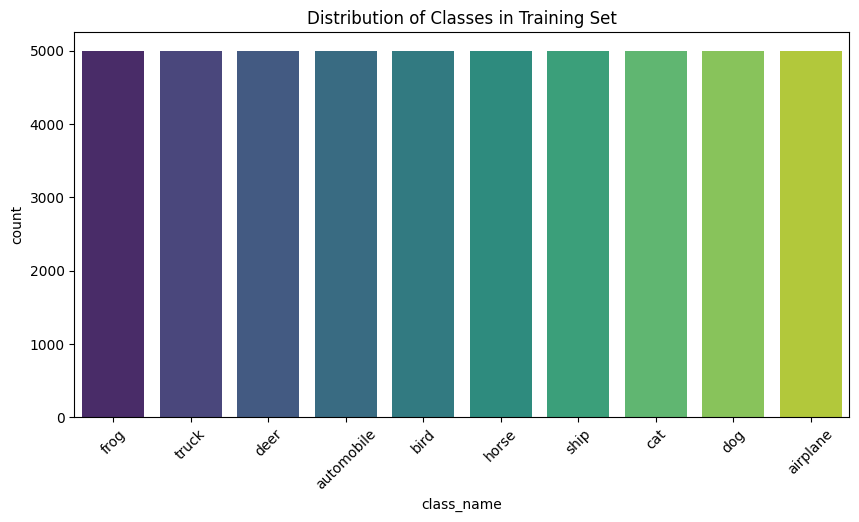

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Create a DataFrame for easy plotting
df_train = pd.DataFrame(y_train, columns=['label'])
df_train['class_name'] = df_train['label'].apply(lambda x: label_names[x])

plt.figure(figsize=(10, 5))
sns.countplot(data=df_train, x='class_name', hue='class_name', palette='viridis', legend=False)
plt.title('Distribution of Classes in Training Set')
plt.xticks(rotation=45)
plt.show()

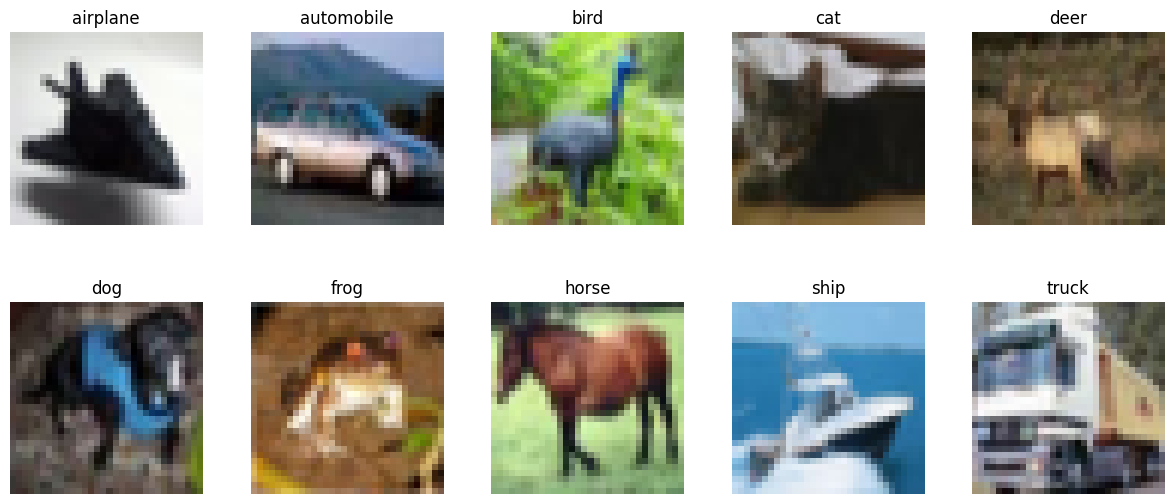

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    # Tìm ảnh đầu tiên của mỗi lớp
    idx = torch.where(y_train == i)[0][0]
    # Chuyển từ (C, H, W) -> (H, W, C) để Matplotlib có thể hiển thị
    img = X_train[idx].permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(label_names[i])
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.show()

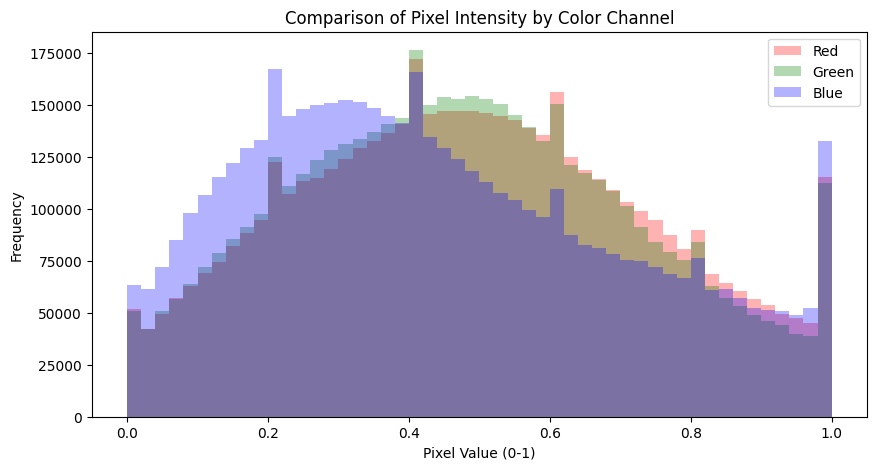

Red Channel - Mean: 0.4921, Std: 0.2454
Green Channel - Mean: 0.4818, Std: 0.2416
Blue Channel - Mean: 0.4457, Std: 0.2598


In [8]:
# Sample for speed
sample_idx = np.random.choice(len(X_train), 5000)
sample_data = X_train[sample_idx] # Shape (5000, 3, 32, 32)

plt.figure(figsize=(10, 5))
# Plot Red, Green, and Blue distributions
# PyTorch: [N, C, H, W] -> C=0: Red, C=1: Green, C=2: Blue
plt.hist(sample_data[:, 0, :, :].flatten().numpy(), bins=50, color='red', alpha=0.3, label='Red')
plt.hist(sample_data[:, 1, :, :].flatten().numpy(), bins=50, color='green', alpha=0.3, label='Green')
plt.hist(sample_data[:, 2, :, :].flatten().numpy(), bins=50, color='blue', alpha=0.3, label='Blue')

plt.legend()
plt.title("Comparison of Pixel Intensity by Color Channel")
plt.xlabel("Pixel Value (0-1)")
plt.ylabel("Frequency")
plt.show()

# Calculate mean and std for each channel (dim 0, 2, 3 are N, H, W)
mean = sample_data.mean(dim=(0, 2, 3))
std = sample_data.std(dim=(0, 2, 3))

# Print specific stats for your report
for i, color in enumerate(['Red', 'Green', 'Blue']):
    print(f"{color} Channel - Mean: {mean[i]:.4f}, Std: {std[i]:.4f}")

In [9]:
from torch.utils.data import DataLoader, TensorDataset, random_split

X_train_norm = X_train.float() / 255.0 if X_train.max() > 1.0 else X_train.float()
X_test_norm = X_test.float() / 255.0 if X_test.max() > 1.0 else X_test.float()
# 1. Tạo Dataset
full_train_dataset = TensorDataset(X_train_norm, y_train)
test_dataset = TensorDataset(X_test_norm, y_test)

# 2. Phân tách tập Validation (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Preprocessing Complete (PyTorch).")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

Preprocessing Complete (PyTorch).
Train samples: 40000, Val samples: 10000, Test samples: 10000


In [30]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Định nghĩa các bước Augmentation (Xoay, Cắt, Normalize Mean/Std)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Đưa về dải quanh số 0
])

test_transform = transforms.Compose([
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Lớp bọc để áp dụng Transform vào TensorDataset
class AugmentedDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.dataset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.dataset)

# KHỞI TẠO DATALOADER (Thấy rõ Loader ở đây)
train_loader = DataLoader(AugmentedDataset(train_dataset, train_transform), batch_size=64, shuffle=True)
val_loader = DataLoader(AugmentedDataset(val_dataset, test_transform), batch_size=64, shuffle=False)
test_loader = DataLoader(AugmentedDataset(test_dataset, test_transform), batch_size=64, shuffle=False)

print("✅ Đã chuẩn hóa 0-1, thiết lập Augmentation và khởi tạo DataLoader thành công!")

✅ Đã chuẩn hóa 0-1, thiết lập Augmentation và khởi tạo DataLoader thành công!


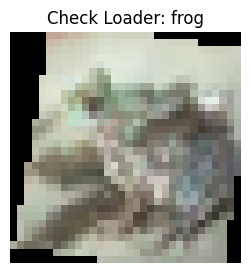

Pixel Range in Loader: [-1.00, 0.86]
Image Shape: torch.Size([3, 32, 32])


In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Lấy 1 batch dữ liệu từ train_loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 2. Chọn ảnh đầu tiên trong batch để hiển thị
img = images[0]
label = labels[0].item()

# 3. Vì chúng ta đã Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# nên ảnh hiện tại đang ở dải [-1, 1]. Cần đưa về [0, 1] để plt.imshow hiển thị đúng màu.
img_display = img * 0.5 + 0.5  # Công thức ngược của Normalize
img_display = img_display.permute(1, 2, 0).numpy() # Chuyển từ (C, H, W) sang (H, W, C)

# 4. Hiển thị
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(5, 3))
plt.imshow(np.clip(img_display, 0, 1)) # Clip để đảm bảo không bị lỗi dải màu
plt.title(f"Check Loader: {label_names[label]}")
plt.axis('off')
plt.show()

# 5. Kiểm tra giá trị Pixel thực tế mô hình nhận được (đã chuẩn hóa quanh 0)
print(f"Pixel Range in Loader: [{img.min():.2f}, {img.max():.2f}]")
print(f"Image Shape: {img.shape}") # Nên là [3, 32, 32]

# Phần 5 LSTM

In [34]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
#

# =====================================================================
# 1. ĐỊNH NGHĨA MÔ HÌNH RNN CHO ẢNH (Hỗ trợ cả LSTM/GRU và Row/Col)
# =====================================================================
class ImageRNN(nn.Module):
    ##
    #
    ##input_size=96: Kích thước đầu vào của mỗi mốc thời gian. Tại sao là 96?
# Vì ảnh CIFAR-10 có kích thước 32x32 pixel và 3 kênh màu (RGB). Nếu ta cắt 1 hàng ngang (hoặc 1 cột dọc) của ảnh,
# ta sẽ có $32 \text{ pixel} \times 3 \text{ kênh màu} = 96$ giá trị.hidden_size=128 & num_layers=2: Ta thiết lập mạng RNN có 2 tầng chồng lên nhau,
# mỗi tầng có bộ nhớ (hidden state) chứa 128 nơ-ron để lưu trữ các đặc trưng của bức ảnh.batch_first=True: Quy định chuẩn tensor đầu vào phải có dạng
# (Batch, Sequence, Features). Nó giúp code dễ đọc hơn so với chuẩn mặc định của PyTorch.self.fc = nn.Linear(...): Đây là lớp phân loại cuối cùng (Fully Connected Layer).
# Nhiệm vụ của nó là nhận bản tóm tắt cuối cùng từ RNN (128 chiều) và phóng ra 10 con số tương ứng với điểm xác suất của 10 lớp vật thể (chó, mèo, máy bay...).
    def __init__(self, input_size=96, hidden_size=256, num_layers=2, num_classes=10, rnn_type='lstm', mode='row'):
        super().__init__()
        self.mode = mode
        self.rnn_type = rnn_type.lower()

        # Cấu trúc linh hoạt: Hỗ trợ cả LSTM và GRU
        if self.rnn_type == 'lstm':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3, bidirectional=True)
        elif self.rnn_type == 'gru':
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3,bidirectional=True)
        else:
            raise ValueError("Chỉ hỗ trợ 'lstm' hoặc 'gru'")

        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):
        #x.permute(...): Lệnh này dùng để tráo đổi vị trí các chiều của Tensor.x.view(...): Lệnh này dùng để gộp các chiều lại với nhau (flatten).Ý nghĩa Quét theo Hàng (mode='row'):
        # Ta xem bức ảnh như một cuốn sách có 32 dòng.Mô hình sẽ đọc tuần tự từ trên xuống dưới.Ở mốc thời gian $t_1$,
        # mô hình đọc hàng pixel trên cùng của ảnh (dài 96 con số).Ở mốc thời gian $t_{32}$, mô hình đọc hàng pixel dưới cùng.
        # Ý nghĩa Quét theo Cột (mode='col'): Ta xem bức ảnh như một mã vạch dọc.Mô hình sẽ đọc tuần tự từ mép trái ảnh sang mép phải ảnh.
        # Đầu vào x: (Batch, Channels, Height, Width) -> (B, 3, 32, 32)
        B, C, H, W = x.shape

        # CHUYỂN ĐỔI ẢNH THÀNH CHUỖI
        if self.mode == 'row':
            # Quét theo hàng: 32 mốc thời gian (H), mỗi mốc chứa 3*32=96 đặc trưng (C*W)
            x = x.permute(0, 2, 1, 3).contiguous()  # (B, H, C, W)
            x = x.view(B, H, C * W)                 # (B, 32, 96)

        elif self.mode == 'col':
            # Quét theo cột: 32 mốc thời gian (W), mỗi mốc chứa 3*32=96 đặc trưng (C*H)
            x = x.permute(0, 3, 1, 2).contiguous()  # (B, W, C, H)
            x = x.view(B, W, C * H)                 # (B, 32, 96)

        # Đưa qua mạng RNN
        out, _ = self.rnn(x)

        # Lấy hidden state ở mốc thời gian cuối cùng để phân loại ảnh
        #out[:, -1, :]: Lệnh này trích xuất ra trạng thái ẩn ở mốc thời gian cuối cùng (phần tử -1 ở chiều Sequence).
        #Ý nghĩa: Mạng RNN có tính chất "nhớ". Khi nó đọc đến hàng pixel cuối cùng của bức ảnh, bộ nhớ của nó (hidden state) lúc này đã chứa đựng sự tóm tắt của toàn bộ 31 hàng pixel trước đó.
        # Do vậy, ta chỉ cần lấy "trí nhớ" ở bước cuối cùng này ném vào hàm phân loại fc là đủ để mạng dự đoán con vật trong ảnh
        final_state = out[:, -1, :]
        return self.fc(final_state)


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
import copy
from sklearn.metrics import precision_score, recall_score, f1_score

def train_and_eval(model, train_loader, test_loader, epochs=10, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Mở rộng history để lưu thêm Precision và Recall
    history = {
        'train_loss': [], 'val_loss': [],
        'val_acc': [], 'val_f1': [],
        'val_precision': [], 'val_recall': []
    }

    best_val_f1 = 0.0
    best_model_state = None

    start_time = time.time()
    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()

        # --- EVALUATION ---
        model.eval()

        val_running_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_running_loss += criterion(outputs, labels).item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Tính toán bộ chỉ số (Dùng average='macro' cho bài toán đa lớp)
        avg_train_loss = running_loss / len(train_loader)
        avg_val_loss = val_running_loss / len(test_loader)
        acc = (np.array(all_preds) == np.array(all_labels)).mean()

        prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

        if f1 > best_val_f1:
            best_val_f1 = f1
            # Lưu lại bản sao trọng số tốt nhất
            best_model_state = copy.deepcopy(model.state_dict())

        # Lưu vào history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(acc)
        history['val_precision'].append(prec)
        history['val_recall'].append(rec)
        history['val_f1'].append(f1)

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {avg_train_loss:.4f} | Val Acc: {acc*100:.2f}% | F1: {f1:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Đã khôi phục trọng số tốt nhất (Best F1: {best_val_f1:.4f})")

    total_time = time.time() - start_time
    print(f"\n✅ Hoàn thành! Tổng thời gian: {total_time:.2f} giây.")

    return history, total_time

In [36]:
# =====================================================================
# 2. KHỞI TẠO VÀ HUẤN LUYỆN SO SÁNH (3 KỊCH BẢN ĐỂ LẤY ĐIỂM TỐI ĐA)
# =====================================================================
EPOCHS = 20

# Khởi tạo 3 cấu hình để thỏa mãn cả 2 yêu cầu: "So sánh 2 kiểu chuỗi" VÀ "So sánh LSTM vs GRU"
models_p5 = {
    "LSTM_Row": ImageRNN(rnn_type='lstm', mode='row'),
    "LSTM_Col": ImageRNN(rnn_type='lstm', mode='col'),
    "GRU_Row":  ImageRNN(rnn_type='gru',  mode='row')
}

results_part5 = {}

for name, model in models_p5.items():
    print(f"\n{'='*50}\nĐANG HUẤN LUYỆN: {name}\n{'='*50}")
    # Lưu ý: Sử dụng lại hàm train_and_eval (có AdamW và Scheduler) đã định nghĩa ở phần trước
    history, t_time = train_and_eval(model, train_loader, test_loader, epochs=EPOCHS)
    results_part5[name] = {"history": history, "time": t_time}


ĐANG HUẤN LUYỆN: LSTM_Row
Epoch [01/20] | Loss: 1.8939 | Val Acc: 38.10% | F1: 0.3678 | LR: 0.000994
Epoch [02/20] | Loss: 1.6561 | Val Acc: 44.14% | F1: 0.4388 | LR: 0.000976
Epoch [03/20] | Loss: 1.5289 | Val Acc: 46.62% | F1: 0.4545 | LR: 0.000946
Epoch [04/20] | Loss: 1.4316 | Val Acc: 49.22% | F1: 0.4861 | LR: 0.000905
Epoch [05/20] | Loss: 1.3557 | Val Acc: 52.74% | F1: 0.5246 | LR: 0.000854
Epoch [06/20] | Loss: 1.2894 | Val Acc: 55.22% | F1: 0.5470 | LR: 0.000794
Epoch [07/20] | Loss: 1.2353 | Val Acc: 55.64% | F1: 0.5467 | LR: 0.000727
Epoch [08/20] | Loss: 1.1811 | Val Acc: 57.05% | F1: 0.5661 | LR: 0.000655
Epoch [09/20] | Loss: 1.1315 | Val Acc: 58.47% | F1: 0.5804 | LR: 0.000578
Epoch [10/20] | Loss: 1.0811 | Val Acc: 60.06% | F1: 0.5955 | LR: 0.000500
Epoch [11/20] | Loss: 1.0375 | Val Acc: 60.65% | F1: 0.6020 | LR: 0.000422
Epoch [12/20] | Loss: 0.9951 | Val Acc: 61.61% | F1: 0.6125 | LR: 0.000345
Epoch [13/20] | Loss: 0.9601 | Val Acc: 62.57% | F1: 0.6240 | LR: 0.00027

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_triple_comparison(histories, class_names):
    # Cấu hình font chữ cho báo cáo khoa học
    plt.rcParams.update({'font.size': 14})
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    ax1, ax2, ax3, ax4 = axes.flatten()

    # Bảng màu: Xanh dương (LSTM Row), Đỏ (LSTM Col), Xanh lá (GRU Row)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    markers = ['o', 's', '^']
    for i, (name, hist) in enumerate(histories.items()):
        epochs = range(1, len(hist["train_loss"]) + 1)

        # 1. Training Loss
        ax1.plot(epochs, hist["train_loss"], marker=markers[i], label=name, color=colors[i])
        ax1.set_title('Training Loss Comparison')

        # 2. Validation Loss
        ax2.plot(epochs, hist["val_loss"], marker=markers[i], label=name, color=colors[i])
        ax2.set_title('Validation Loss Comparison')

        # 3. Accuracy
        ax3.plot(epochs, [a * 100 for a in hist["val_acc"]], marker=markers[i], label=name, color=colors[i])
        ax3.set_title('Validation Accuracy (%)')

        # 4. F1-Score
        ax4.plot(epochs, hist["val_f1"], marker=markers[i], label=name, color=colors[i])
        ax4.set_title('F1-Score (Macro)')

    for ax in [ax1, ax2, ax3, ax4]:
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()
        ax.set_xlabel('Epochs')

    plt.tight_layout()
    plt.show()

BANG SO SANH HIEU NANG CAC KIEN TRUC RNN (PART 5):


,Model Architecture,Best Accuracy (%),Best F1-Score,Precision,Recall,Training Time (s)
0,LSTM_Row,63.89%,0.6367,0.6360,0.6389,834.10
1,LSTM_Col,60.78%,0.6061,0.6055,0.6078,826.45
2,GRU_Row,68.22%,0.6812,0.6811,0.6822,779.77


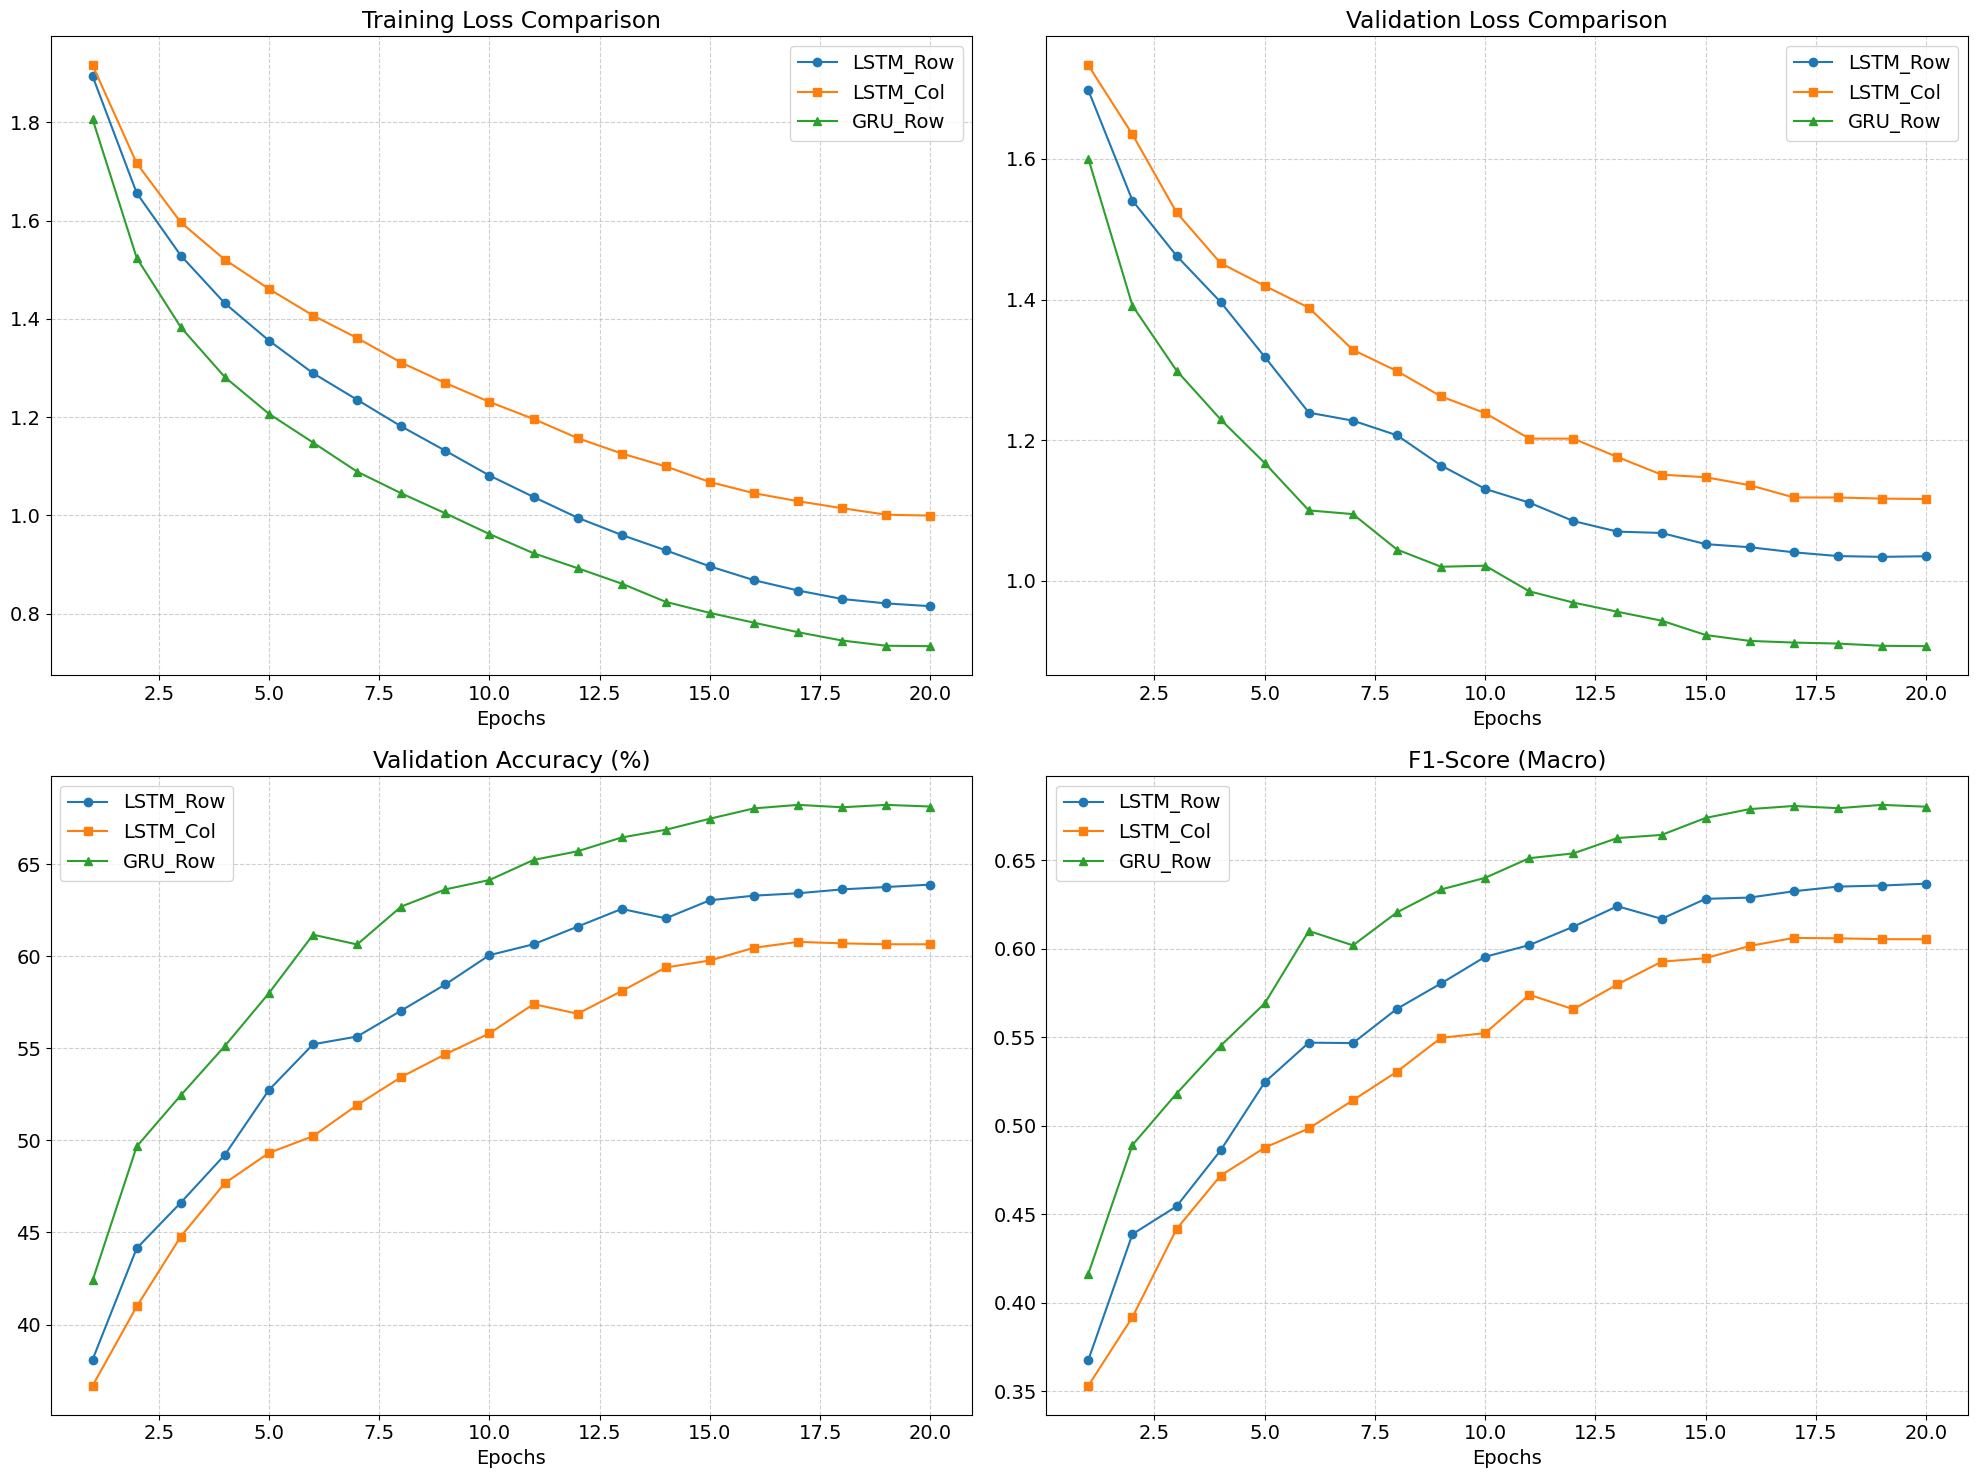

In [74]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def summarize_results(results_dict):
    summary_data = []

    for name, data in results_dict.items():
        hist = data["history"]
        t_time = data["time"]

        # Tìm vị trí epoch có F1-Score cao nhất để lấy chỉ số tốt nhất
        best_idx = np.argmax(hist['val_f1'])

        summary_data.append({
            "Model Architecture": name,
            "Best Accuracy (%)": f"{hist['val_acc'][best_idx]*100:.2f}%",
            "Best F1-Score": f"{hist['val_f1'][best_idx]:.4f}",
            "Precision": f"{hist['val_precision'][best_idx]:.4f}",
            "Recall": f"{hist['val_recall'][best_idx]:.4f}",
            "Training Time (s)": f"{t_time:.2f}"
        })

    return pd.DataFrame(summary_data)

# 2. Trích xuất histories riêng để phục vụ hàm vẽ plot_triple_comparison
all_histories = {name: data["history"] for name, data in results_part5.items()}

# 3. Hiển thị bảng số liệu
df_final = summarize_results(results_part5)
print("BANG SO SANH HIEU NANG CAC KIEN TRUC RNN (PART 5):")
display(df_final)

# 4. Gọi hàm vẽ biểu đồ (Sử dụng dict all_histories vừa trích xuất)
# Đảm bảo bạn đã định nghĩa class_names trước đó
plot_triple_comparison(all_histories, class_names)

In [64]:
import torch

# Thiết lập device: ưu tiên 'cuda' (GPU), nếu không có thì dùng 'cpu'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Thiết bị đang sử dụng: {device}")
# Nếu hiện 'cuda', chúc mừng bạn, tốc độ train sẽ rất nhanh!

Thiết bị đang sử dụng: cuda


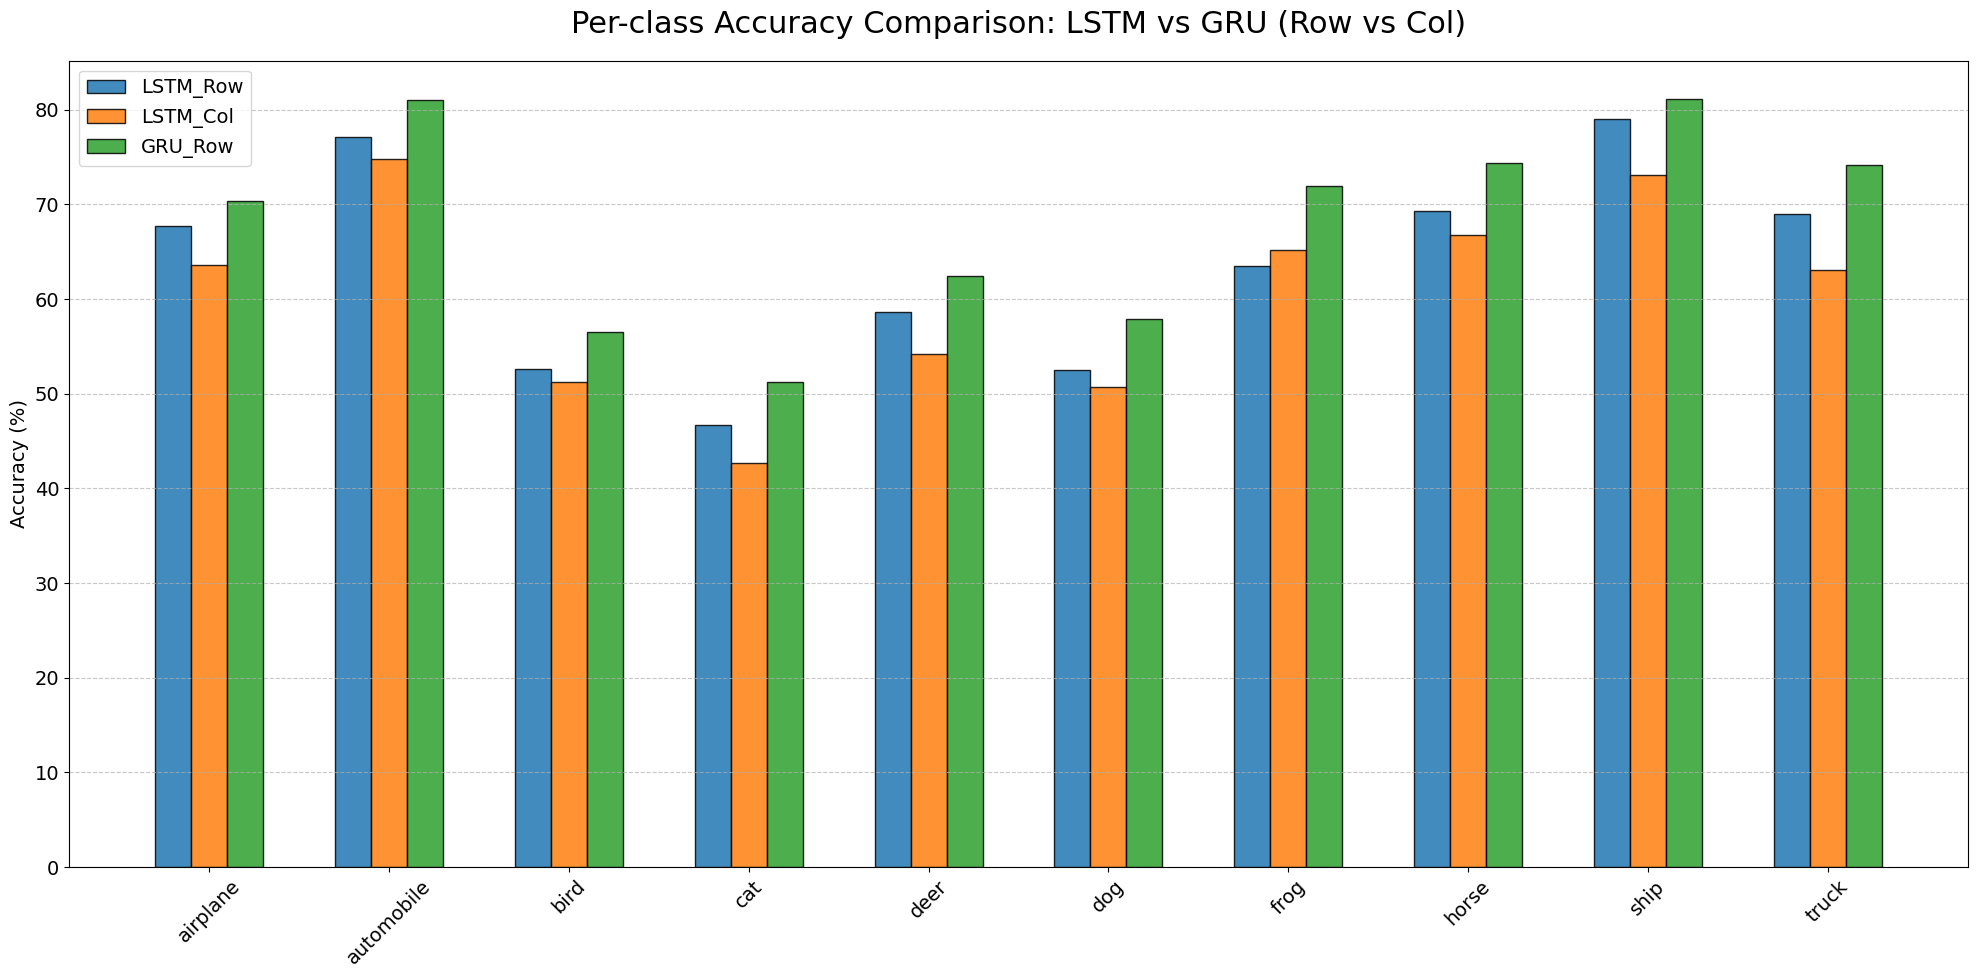

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

def plot_per_class_comparison(results_dict, models_dict, test_loader, class_names, device):
    per_class_accs = {}

    for name, data in results_dict.items():
        # Lấy model trực tiếp từ từ điển models_p5 ban đầu
        model = models_dict[name].to(device)
        model.eval()

        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
        per_class_accs[name] = [report[cls]['precision'] * 100 for cls in class_names]

    plt.rcParams.update({'font.size': 14})


    # 2. Vẽ biểu đồ Grouped Bar Chart
    x = np.arange(len(class_names))
    width = 0.2  # Độ rộng của mỗi cột

    fig, ax = plt.subplots(figsize=(20, 10))

    # Định nghĩa màu sắc tương ứng với các marker trước đó
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    for i, (name, accs) in enumerate(per_class_accs.items()):
        ax.bar(x + (i - 1) * width, accs, width, label=name, color=colors[i], alpha=0.85, edgecolor='black')

    # Định dạng trục
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Per-class Accuracy Comparison: LSTM vs GRU (Row vs Col)', fontsize=22, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45)
    ax.legend(fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Gọi hàm (Giả sử bạn đã lưu model vào kết quả huấn luyện)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plot_per_class_comparison(results_part5, models_p5, test_loader, class_names, device)